# Phase 1: Joint MoE expert training (reference config)

Validates `train_joint_moe` on the spec reference settings:
`contamination=0.05`, `cluster_sep=1.5`, data `seed=0`. Uses distinct seeds for independent vs joint expert training so initialization differs across regimes.

See `specs/moe_joint.md` Phase 1 checklist: CE decreases, non-collapsed gates, holdout accuracy, ε diagnostic vs independent training.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
project_root = next((p for p in candidates if (p / "moe_bandit").exists()), None)
if project_root is None:
    raise RuntimeError("Could not find project root containing 'moe_bandit'.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from moe_bandit.data import generate_synthetic_data
from moe_bandit.experts import expert_reward_matrix, train_experts
from moe_bandit.linear_approx_error import linear_approx_max_error
from moe_bandit.train_joint_moe import train_joint_moe

In [2]:
# Reference configuration (specs/moe_joint.md § Phase 1 validation target)
K = 4
d = 4
cluster_sep = 1.5
cluster_std = 1.0
contamination = 0.05
seed_train_data = 0
n_train_per_cluster = 2000
n_train_total = K * n_train_per_cluster

seed_experts_independent = 303
seed_experts_joint = 202

X_train, y_train, cluster_train = generate_synthetic_data(
    n_samples=n_train_total,
    K=K,
    d=d,
    cluster_sep=cluster_sep,
    cluster_std=cluster_std,
    seed=seed_train_data,
)

In [3]:
experts_indep = train_experts(
    X_train=X_train,
    y_train=y_train,
    cluster_id_train=cluster_train,
    K=K,
    d=d,
    epochs=30,
    lr=1e-3,
    batch_size=64,
    seed=seed_experts_independent,
    contamination=contamination,
)

experts_joint, stats_joint = train_joint_moe(
    X_train=X_train,
    y_train=y_train,
    cluster_id_train=cluster_train,
    K=K,
    d=d,
    epochs=200,
    lr=1e-3,
    lr_min=1e-5,
    cosine_decay=True,
    batch_size=64,
    seed=seed_experts_joint,
    alpha_load=1e-3,
    val_frac=0.1,
    early_stopping_patience=20,
    router="linear",
)

print("independent experts:", len(experts_indep))
print("joint experts:", len(experts_joint))
print("epochs run:", stats_joint.epochs_run, "early_stopped:", stats_joint.early_stopped)
print("best val acc:", stats_joint.best_val_acc, "at epoch", stats_joint.best_epoch_1based)
print("checkpoint val acc:", stats_joint.final_pooled_val_acc)
print("final joint gate means:", stats_joint.final_gate_means)
print("collapse warning (epoch 5):", stats_joint.collapse_warning_early)
for m in stats_joint.collapse_warning_messages:
    print(m)

[joint MoE] training complete: early stop after 44 epochs; best val acc=0.7025 (epoch 24), checkpoint train acc=0.7040, checkpoint val acc=0.7025, gate means=[0.2524, 0.2897, 0.1971, 0.2608]
independent experts: 4
joint experts: 4
epochs run: 44 early_stopped: True
best val acc: 0.7025 at epoch 24
checkpoint val acc: 0.7025
final joint gate means: [0.25240692 0.28969383 0.19709866 0.26080057]
collapse warning (epoch 5): False


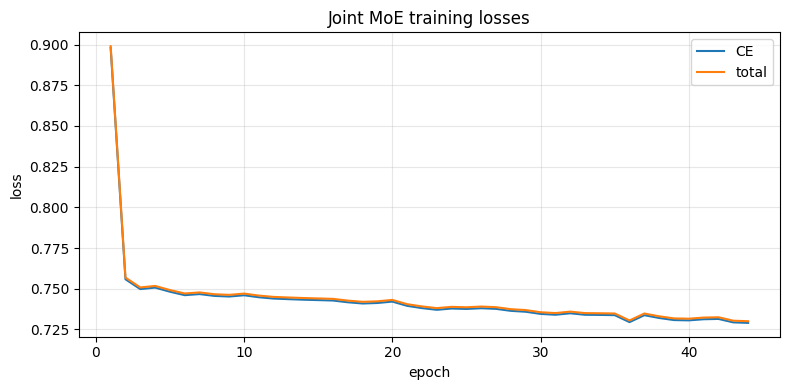

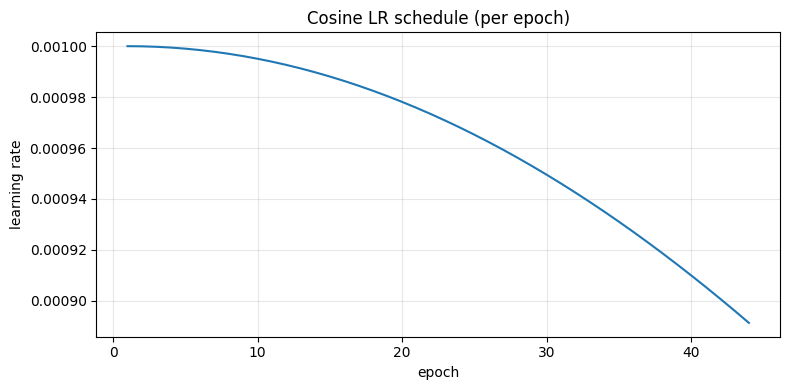

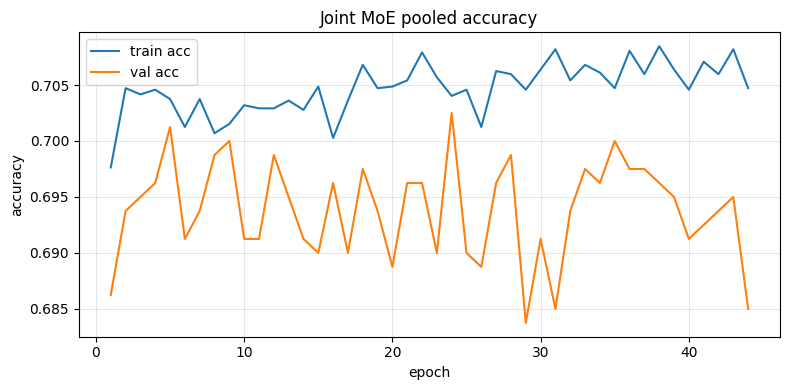

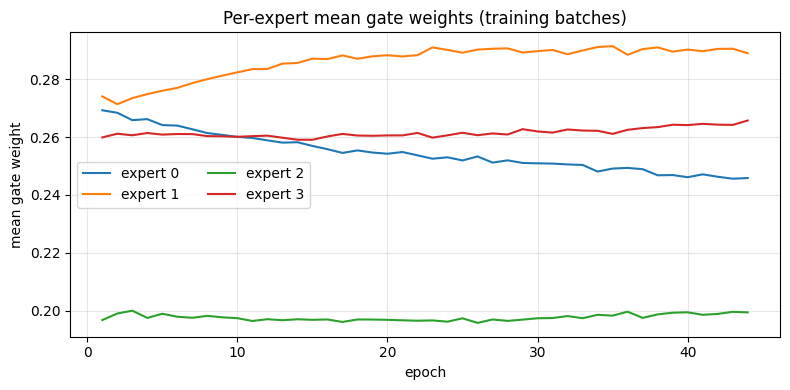

In [4]:
epochs = np.arange(1, len(stats_joint.history_ce_loss) + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, stats_joint.history_ce_loss, label="CE")
plt.plot(epochs, stats_joint.history_total_loss, label="total")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Joint MoE training losses")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, stats_joint.history_lr)
plt.xlabel("epoch")
plt.ylabel("learning rate")
plt.title("Cosine LR schedule (per epoch)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, stats_joint.history_train_acc, label="train acc")
plt.plot(epochs, stats_joint.history_val_acc, label="val acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Joint MoE pooled accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

gate_hist = np.stack(stats_joint.history_gate_means, axis=0)
plt.figure(figsize=(8, 4))
for i in range(K):
    plt.plot(epochs, gate_hist[:, i], label=f"expert {i}")
plt.xlabel("epoch")
plt.ylabel("mean gate weight")
plt.title("Per-expert mean gate weights (training batches)")
plt.legend(ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

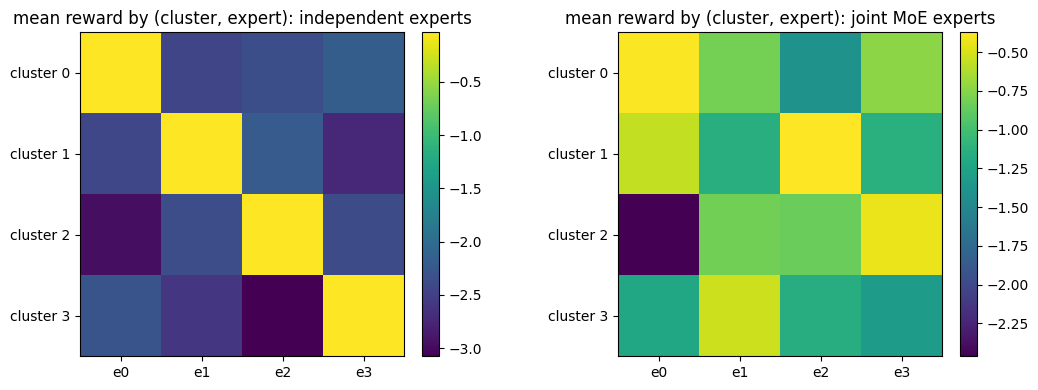

In [7]:
R_indep = expert_reward_matrix(experts=experts_indep, X=X_train, y=y_train, clip_eps=1e-3)
R_joint = expert_reward_matrix(experts=experts_joint, X=X_train, y=y_train, clip_eps=1e-3)

mean_indep = np.vstack([R_indep[cluster_train == i].mean(axis=0) for i in range(K)])
mean_joint = np.vstack([R_joint[cluster_train == i].mean(axis=0) for i in range(K)])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, mat, title in [
    (axes[0], mean_indep, "independent experts"),
    (axes[1], mean_joint, "joint MoE experts"),
]:
    im = ax.imshow(mat, cmap="viridis")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(np.arange(K))
    ax.set_xticklabels([f"e{i}" for i in range(K)])
    ax.set_yticks(np.arange(K))
    ax.set_yticklabels([f"cluster {i}" for i in range(K)])
    ax.set_title(f"mean reward by (cluster, expert): {title}")
plt.tight_layout()
plt.show()

In [8]:
eps_indep = linear_approx_max_error(R_indep, X_train, lambda_reg=1.0, fit_intercept=True)
eps_joint = linear_approx_max_error(R_joint, X_train, lambda_reg=1.0, fit_intercept=True)

print("ridge λ =", eps_indep.lambda_reg, "intercept =", eps_indep.fit_intercept)
print("mean ε independent:", eps_indep.mean_epsilon)
print("mean ε joint:", eps_joint.mean_epsilon)
print("per-arm ε independent:", np.round(eps_indep.epsilon_per_arm, 4))
print("per-arm ε joint:", np.round(eps_joint.epsilon_per_arm, 4))

ridge λ = 1.0 intercept = True
mean ε independent: 5.367155891176958
mean ε joint: 5.564446898599842
per-arm ε independent: [5.2524 5.4837 5.2876 5.4449]
per-arm ε joint: [6.0532 6.109  5.9605 4.1352]


In [9]:
import numpy as np

lambda_reg = 1.0
X = X_train  # same contexts used to build R
T, d = X.shape
X_aug = np.concatenate([X, np.ones((T, 1))], axis=1)

def rmse_per_arm(R: np.ndarray) -> np.ndarray:
    _, K = R.shape
    reg = lambda_reg * np.eye(d + 1)
    xtx = X_aug.T @ X_aug + reg
    out = np.zeros(K)
    for i in range(K):
        theta = np.linalg.solve(xtx, X_aug.T @ R[:, i])
        pred = X_aug @ theta
        out[i] = np.sqrt(np.mean((R[:, i] - pred) ** 2))
    return out

rmse_indep = rmse_per_arm(R_indep)
rmse_joint = rmse_per_arm(R_joint)
print("mean RMSE indep:", rmse_indep.mean())
print("mean RMSE joint:", rmse_joint.mean())

mean RMSE indep: 1.8991052184334742
mean RMSE joint: 0.9640227556976575
